# Common Libraries Analysis (RQ4 Option A)

**Research Question**: What are the most common libraries used/adopted by AI agents?

This notebook analyzes:
1. Most commonly **imported** libraries (in code)
2. Most commonly **adopted** libraries (newly added to dependency files)
3. Patterns across languages (testing frameworks, AI libraries, type systems)
4. Category analysis (production vs development libraries)

In [1]:
import sys

sys.path.append("..")

import json
import pandas as pd
import numpy as np
from pathlib import Path
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns

data_dir = Path("../data")
output_dir = Path("../output")

# Set style
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

## Load Analysis Results

In [2]:
# Load results for each language
# Use explicit mapping to ensure consistent capitalization
lang_mapping = {"go": "Go", "python": "Python", "typescript": "TypeScript"}

results_by_lang = {}

for lang_key, lang_name in lang_mapping.items():
    with open(output_dir / f"{lang_key}_library_usage.json", "r") as f:
        results_by_lang[lang_name] = json.load(f)

print("Loaded results:")
for lang, results in results_by_lang.items():
    print(f"  {lang}: {len(results):,} PRs")

Loaded results:
  Go: 10,107 PRs
  Python: 7,190 PRs
  TypeScript: 6,494 PRs


## Most Commonly Imported Libraries (Overall Usage)

These are libraries found in code imports across all PRs.

In [3]:
print("=" * 70)
print("MOST COMMONLY IMPORTED LIBRARIES (All Usage)")
print("=" * 70)

common_libs_data = []

for lang, results in results_by_lang.items():
    print(f"\n{lang}:")
    print("-" * 70)

    # Count all library occurrences across PRs
    lib_counter = Counter()
    for pr in results:
        # Count each library once per PR (not multiple times if imported multiple times)
        libs = set(pr.get("all_libraries", []))
        lib_counter.update(libs)

    # Top 15 for analysis
    top_libs = lib_counter.most_common(15)

    print(f"Top 15 (out of {len(lib_counter):,} unique libraries):\n")
    for i, (lib, count) in enumerate(top_libs, 1):
        pct = 100 * count / len(results)
        print(f"  {i:2d}. {lib:35s} {count:5,} PRs ({pct:5.1f}%)")

        common_libs_data.append(
            {
                "Language": lang,
                "Library": lib,
                "Count": count,
                "Percentage": pct,
                "Rank": i,
            }
        )

df_common_libs = pd.DataFrame(common_libs_data)

MOST COMMONLY IMPORTED LIBRARIES (All Usage)

Go:
----------------------------------------------------------------------
Top 15 (out of 696 unique libraries):

   1. fmt                                   853 PRs (  8.4%)
   2. testing                               727 PRs (  7.2%)
   3. os                                    716 PRs (  7.1%)
   4. strings                               685 PRs (  6.8%)
   5. path/filepath                         602 PRs (  6.0%)
   6. mochi/parser                          576 PRs (  5.7%)
   7. bytes                                 559 PRs (  5.5%)
   8. mochi/types                           512 PRs (  5.1%)
   9. os/exec                               495 PRs (  4.9%)
  10. time                                  247 PRs (  2.4%)
  11. encoding/json                         204 PRs (  2.0%)
  12. mochi/compiler/x                      183 PRs (  1.8%)
  13. context                               154 PRs (  1.5%)
  14. strconv                               141

## Most Commonly ADOPTED Libraries (New Additions)

These are libraries newly added to dependency files by agents.

In [4]:
print("=" * 70)
print("MOST COMMONLY ADOPTED LIBRARIES (New Additions Only)")
print("=" * 70)

new_libs_data = []

for lang, results in results_by_lang.items():
    print(f"\n{lang}:")
    print("-" * 70)

    # Count new library occurrences
    new_lib_counter = Counter()
    for pr in results:
        new_libs = pr.get("new_libraries", [])
        new_lib_counter.update(new_libs)

    # Top 15
    top_new_libs = new_lib_counter.most_common(15)

    # Count PRs that added new libraries
    prs_with_new = sum(1 for pr in results if pr.get("new_libraries"))

    print(f"Top 15 (from {prs_with_new:,} PRs that added new libraries):\n")
    for i, (lib, count) in enumerate(top_new_libs, 1):
        pct = 100 * count / prs_with_new if prs_with_new > 0 else 0
        print(f"  {i:2d}. {lib:35s} {count:5,} PRs ({pct:5.1f}%)")

        new_libs_data.append(
            {
                "Language": lang,
                "Library": lib,
                "Count": count,
                "Percentage": pct,
                "Rank": i,
            }
        )

df_new_libs = pd.DataFrame(new_libs_data)

MOST COMMONLY ADOPTED LIBRARIES (New Additions Only)

Go:
----------------------------------------------------------------------
Top 15 (from 16 PRs that added new libraries):

   1. github.com/golang/snappy                6 PRs ( 37.5%)
   2. github.com/stretchr/testify             3 PRs ( 18.8%)
   3. gopkg.in/yaml.v3                        3 PRs ( 18.8%)
   4. github.com/klauspost/reedsolomon        3 PRs ( 18.8%)
   5. github.com/gogo/protobuf                3 PRs ( 18.8%)
   6. go.uber.org/atomic                      2 PRs ( 12.5%)
   7. github.com/smacker/go-tree-sitter       2 PRs ( 12.5%)
   8. github.com/alingse/asasalint            1 PRs (  6.2%)
   9. github.com/gobwas/glob                  1 PRs (  6.2%)
  10. github.com/go-toolsmith/typep           1 PRs (  6.2%)
  11. github.com/ldez/gomoddirectives         1 PRs (  6.2%)
  12. github.com/kisielk/errcheck             1 PRs (  6.2%)
  13. github.com/golangci/revgrep             1 PRs (  6.2%)
  14. github.com/golangci/dupl

## Visualization: Top 10 Libraries by Language

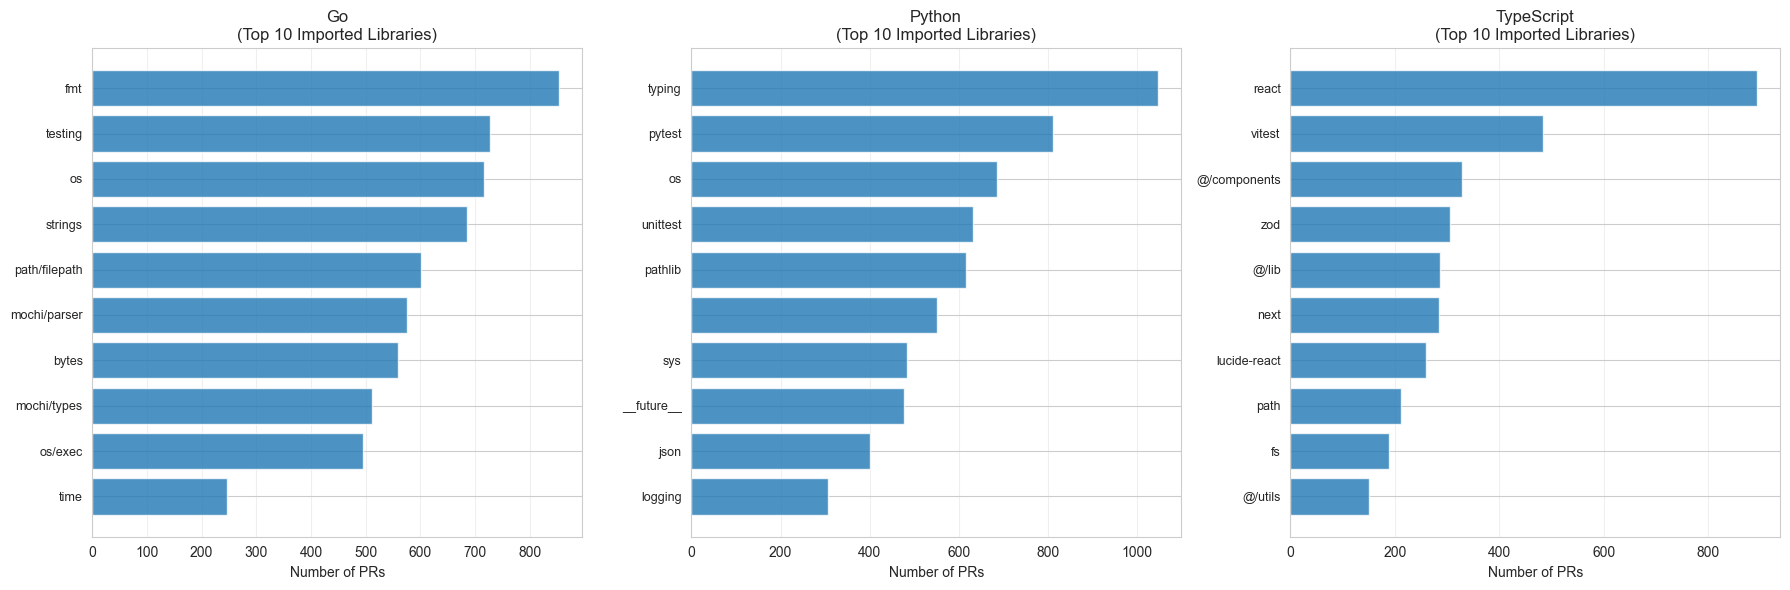


Saved: ../output/top_libraries_imported.png


In [5]:
# Create horizontal bar charts for top 10 per language
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for idx, (lang, ax) in enumerate(zip(["Go", "Python", "TypeScript"], axes)):
    # Get top 10 for this language
    lang_data = df_common_libs[df_common_libs["Language"] == lang].head(10)

    # Plot
    y_pos = np.arange(len(lang_data))
    ax.barh(y_pos, lang_data["Count"], alpha=0.8)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(lang_data["Library"], fontsize=9)
    ax.invert_yaxis()  # Top to bottom
    ax.set_xlabel("Number of PRs")
    ax.set_title(f"{lang}\n(Top 10 Imported Libraries)")
    ax.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.savefig(output_dir / "top_libraries_imported.png", dpi=300, bbox_inches="tight")
plt.show()

print(f"\nSaved: {output_dir / 'top_libraries_imported.png'}")

## Visualization: Top 10 Newly Adopted Libraries

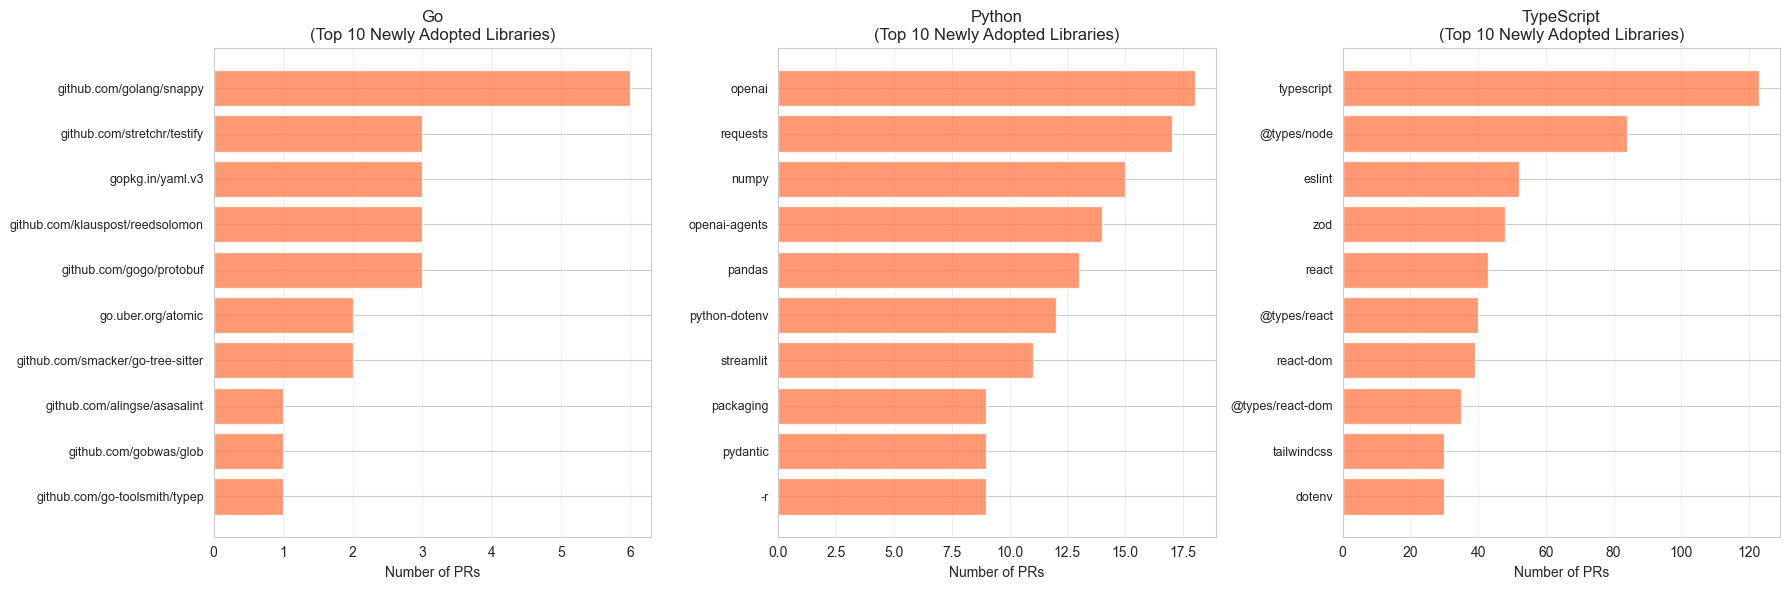


Saved: ../output/top_libraries_adopted.png


In [6]:
# Create horizontal bar charts for top 10 NEW libraries per language
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for idx, (lang, ax) in enumerate(zip(["Go", "Python", "TypeScript"], axes)):
    # Get top 10 new libraries for this language
    lang_data = df_new_libs[df_new_libs["Language"] == lang].head(10)

    if len(lang_data) == 0:
        ax.text(0.5, 0.5, "No data", ha="center", va="center", transform=ax.transAxes)
        ax.set_title(f"{lang}\n(Top 10 Newly Adopted)")
        continue

    # Plot
    y_pos = np.arange(len(lang_data))
    ax.barh(y_pos, lang_data["Count"], alpha=0.8, color="coral")
    ax.set_yticks(y_pos)
    ax.set_yticklabels(lang_data["Library"], fontsize=9)
    ax.invert_yaxis()
    ax.set_xlabel("Number of PRs")
    ax.set_title(f"{lang}\n(Top 10 Newly Adopted Libraries)")
    ax.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.savefig(output_dir / "top_libraries_adopted.png", dpi=300, bbox_inches="tight")
plt.show()

print(f"\nSaved: {output_dir / 'top_libraries_adopted.png'}")

## Library Category Analysis

Classify libraries by purpose to identify patterns.

In [7]:
# Define common library categories
categories = {
    "Testing": {
        "pytest",
        "unittest",
        "jest",
        "vitest",
        "mocha",
        "chai",
        "jasmine",
        "testing",
        "testify",
        "@testing-library/react",
        "@testing-library/jest-dom",
    },
    "Type Systems": {
        "typescript",
        "mypy",
        "typing",
        "@types/node",
        "@types/react",
        "@types/react-dom",
        "typing_extensions",
        "types-requests",
    },
    "AI/ML": {
        "openai",
        "anthropic",
        "numpy",
        "pandas",
        "scikit-learn",
        "tensorflow",
        "torch",
        "transformers",
        "langchain",
        "llama-index",
    },
    "Web Frameworks": {
        "react",
        "react-dom",
        "next",
        "express",
        "fastapi",
        "flask",
        "django",
        "gin",
        "echo",
        "fiber",
    },
    "Code Quality": {
        "eslint",
        "prettier",
        "black",
        "ruff",
        "flake8",
        "pylint",
        "isort",
        "golangci-lint",
        "pre-commit",
    },
    "UI Components": {
        "lucide-react",
        "@radix-ui",
        "tailwindcss",
        "clsx",
        "shadcn",
        "@mui/material",
        "antd",
    },
    "Validation": {"zod", "pydantic", "joi", "yup", "ajv", "jsonschema"},
    "HTTP/Requests": {"requests", "axios", "fetch", "httpx", "urllib3", "aiohttp"},
    "Database": {
        "sqlalchemy",
        "prisma",
        "mongoose",
        "pg",
        "mysql",
        "redis",
        "gorm",
        "ent",
    },
    "Utilities": {
        "lodash",
        "underscore",
        "dotenv",
        "python-dotenv",
        "pathlib",
        "os",
        "sys",
        "json",
        "time",
        "path",
        "fs",
        "fmt",
        "strings",
    },
}


def categorize_library(lib_name):
    """Categorize a library by its name."""
    lib_lower = lib_name.lower()

    for category, libs in categories.items():
        if lib_lower in {_l.lower() for _l in libs}:
            return category
        # Check partial matches for scoped packages
        for pattern in libs:
            if pattern.lower() in lib_lower:
                return category

    return "Other"


# Categorize all libraries
df_common_libs["Category"] = df_common_libs["Library"].apply(categorize_library)
df_new_libs["Category"] = df_new_libs["Library"].apply(categorize_library)

print("Library categorization complete!")

Library categorization complete!


In [8]:
# Category distribution for imported libraries
print("=" * 70)
print("CATEGORY DISTRIBUTION (Imported Libraries)")
print("=" * 70)

for lang in ["Go", "Python", "TypeScript"]:
    print(f"\n{lang}:")
    lang_data = df_common_libs[df_common_libs["Language"] == lang].head(30)  # Top 30
    category_counts = lang_data["Category"].value_counts()

    for category, count in category_counts.items():
        print(f"  {category:20s} {count:2d} libraries")

CATEGORY DISTRIBUTION (Imported Libraries)

Go:
  Utilities             7 libraries
  Other                 7 libraries
  Testing               1 libraries

Python:
  Utilities             5 libraries
  Other                 5 libraries
  Testing               2 libraries
  Type Systems          1 libraries
  Web Frameworks        1 libraries
  Validation            1 libraries

TypeScript:
  Utilities             4 libraries
  Web Frameworks        3 libraries
  Other                 3 libraries
  Testing               2 libraries
  Database              1 libraries
  Validation            1 libraries
  Type Systems          1 libraries


In [9]:
# Category distribution for newly adopted libraries
print("=" * 70)
print("CATEGORY DISTRIBUTION (Newly Adopted Libraries)")
print("=" * 70)

for lang in ["Go", "Python", "TypeScript"]:
    print(f"\n{lang}:")
    lang_data = df_new_libs[df_new_libs["Language"] == lang].head(30)

    if len(lang_data) == 0:
        print("  No data")
        continue

    category_counts = lang_data["Category"].value_counts()

    for category, count in category_counts.items():
        print(f"  {category:20s} {count:2d} libraries")

CATEGORY DISTRIBUTION (Newly Adopted Libraries)

Go:
  Other                12 libraries
  Utilities             2 libraries
  Testing               1 libraries

Python:
  AI/ML                 4 libraries
  Other                 4 libraries
  HTTP/Requests         3 libraries
  Utilities             1 libraries
  Web Frameworks        1 libraries
  Validation            1 libraries
  Type Systems          1 libraries

TypeScript:
  Type Systems          4 libraries
  Web Frameworks        3 libraries
  Utilities             2 libraries
  Other                 2 libraries
  Code Quality          1 libraries
  Validation            1 libraries
  UI Components         1 libraries
  Testing               1 libraries


## Visualization: Category Distribution

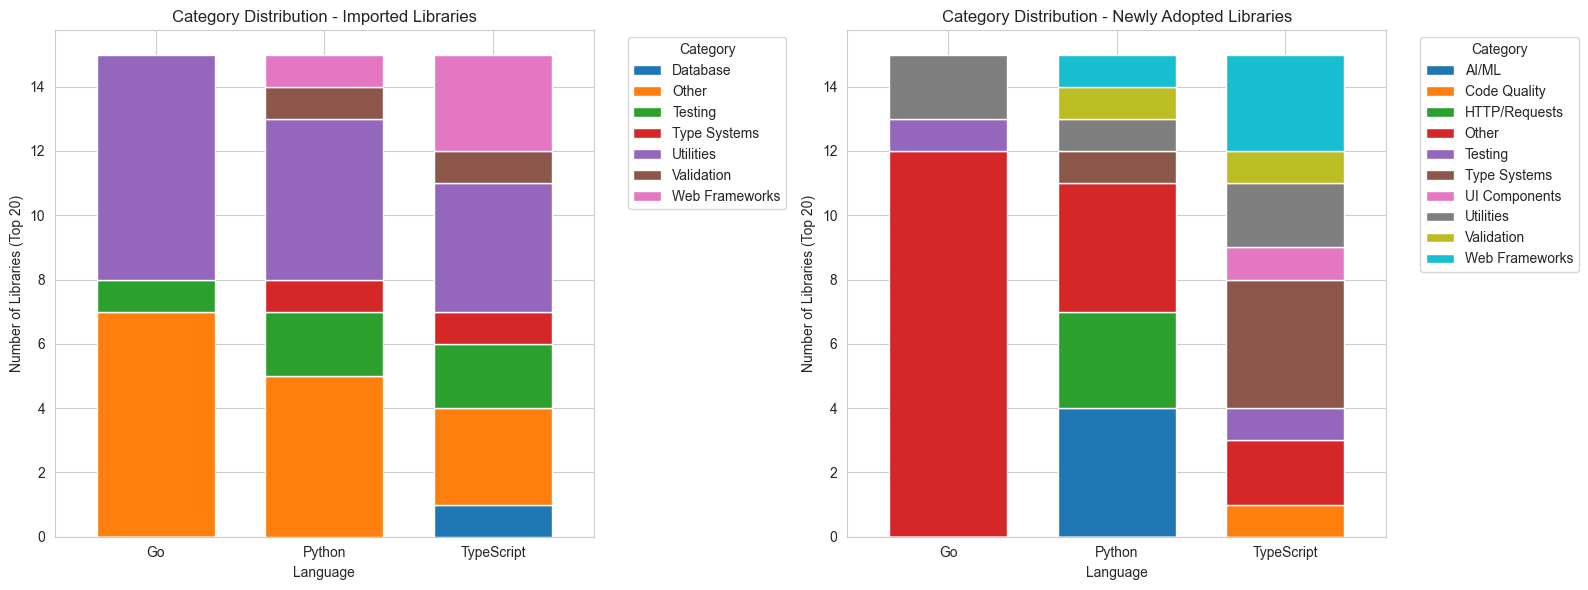


Saved: ../output/library_categories.png


In [10]:
# Create stacked bar chart for categories
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Left: Imported libraries
category_by_lang = []
for lang in ["Go", "Python", "TypeScript"]:
    lang_data = df_common_libs[df_common_libs["Language"] == lang].head(20)
    category_counts = lang_data["Category"].value_counts()
    for cat, count in category_counts.items():
        category_by_lang.append({"Language": lang, "Category": cat, "Count": count})

df_cat = pd.DataFrame(category_by_lang)
df_cat_pivot = df_cat.pivot_table(
    index="Language", columns="Category", values="Count", fill_value=0
)

df_cat_pivot.plot(kind="bar", stacked=True, ax=ax1, width=0.7)
ax1.set_ylabel("Number of Libraries (Top 20)")
ax1.set_xlabel("Language")
ax1.set_title("Category Distribution - Imported Libraries")
ax1.legend(title="Category", bbox_to_anchor=(1.05, 1), loc="upper left")
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=0)

# Right: Newly adopted libraries
new_category_by_lang = []
for lang in ["Go", "Python", "TypeScript"]:
    lang_data = df_new_libs[df_new_libs["Language"] == lang].head(20)
    if len(lang_data) > 0:
        category_counts = lang_data["Category"].value_counts()
        for cat, count in category_counts.items():
            new_category_by_lang.append(
                {"Language": lang, "Category": cat, "Count": count}
            )

if new_category_by_lang:
    df_new_cat = pd.DataFrame(new_category_by_lang)
    df_new_cat_pivot = df_new_cat.pivot_table(
        index="Language", columns="Category", values="Count", fill_value=0
    )

    df_new_cat_pivot.plot(kind="bar", stacked=True, ax=ax2, width=0.7)
    ax2.set_ylabel("Number of Libraries (Top 20)")
    ax2.set_xlabel("Language")
    ax2.set_title("Category Distribution - Newly Adopted Libraries")
    ax2.legend(title="Category", bbox_to_anchor=(1.05, 1), loc="upper left")
    ax2.set_xticklabels(ax2.get_xticklabels(), rotation=0)

plt.tight_layout()
plt.savefig(output_dir / "library_categories.png", dpi=300, bbox_inches="tight")
plt.show()

print(f"\nSaved: {output_dir / 'library_categories.png'}")

## Key Patterns and Insights

In [11]:
print("=" * 70)
print("KEY PATTERNS FOR PAPER")
print("=" * 70)

print("\n1. TESTING DOMINATES")
print("-" * 70)
testing_libs = df_common_libs[df_common_libs["Category"] == "Testing"]
print("Testing libraries appear in top 15 across all languages:")
for lang in ["Go", "Python", "TypeScript"]:
    lang_testing = testing_libs[testing_libs["Language"] == lang]
    if len(lang_testing) > 0:
        print(f"  {lang}: {', '.join(lang_testing['Library'].tolist())}")

print("\n2. TYPE SYSTEMS POPULAR")
print("-" * 70)
type_libs = df_common_libs[df_common_libs["Category"] == "Type Systems"]
print("Type-related libraries show language preferences:")
for lang in ["Python", "TypeScript"]:
    lang_types = type_libs[type_libs["Language"] == lang]
    if len(lang_types) > 0:
        print(f"  {lang}: {', '.join(lang_types['Library'].tolist())}")

print("\n3. AI/ML LIBRARIES EMERGING")
print("-" * 70)
ai_libs = df_new_libs[df_new_libs["Category"] == "AI/ML"]
if len(ai_libs) > 0:
    print("AI/ML libraries in newly adopted (reflects agent use cases):")
    for _, row in ai_libs.head(10).iterrows():
        print(f"  {row['Language']:12s} {row['Library']:25s} {row['Count']:3d} PRs")
else:
    print("No AI/ML libraries in top newly adopted")

print("\n4. LANGUAGE-SPECIFIC PATTERNS")
print("-" * 70)
print("Go: Heavy stdlib usage (fmt, testing, os, strings)")
print("Python: Type annotations (typing), data science (numpy, pandas), AI (openai)")
print("TypeScript: React ecosystem, type definitions (@types/*), zod validation")

print("\n5. PRACTICAL vs TRAINING DATA")
print("-" * 70)
print("Common patterns suggest mix of:")
print("  - Practical developer needs (testing frameworks, type systems)")
print("  - Training data influence (popular libraries like react, openai)")
print("  - Project-specific requirements (web frameworks, databases)")

KEY PATTERNS FOR PAPER

1. TESTING DOMINATES
----------------------------------------------------------------------
Testing libraries appear in top 15 across all languages:
  Go: testing
  Python: pytest, unittest
  TypeScript: vitest, @testing-library/react

2. TYPE SYSTEMS POPULAR
----------------------------------------------------------------------
Type-related libraries show language preferences:
  Python: typing
  TypeScript: typescript

3. AI/ML LIBRARIES EMERGING
----------------------------------------------------------------------
AI/ML libraries in newly adopted (reflects agent use cases):
  Python       openai                     18 PRs
  Python       numpy                      15 PRs
  Python       openai-agents              14 PRs
  Python       pandas                     13 PRs

4. LANGUAGE-SPECIFIC PATTERNS
----------------------------------------------------------------------
Go: Heavy stdlib usage (fmt, testing, os, strings)
Python: Type annotations (typing), data sci

## Export Results for Paper

In [12]:
# Create summary tables for paper
summary_tables = {}

for lang in ["Go", "Python", "TypeScript"]:
    # Top 10 imported
    imported = df_common_libs[df_common_libs["Language"] == lang].head(10)

    # Top 10 newly adopted
    adopted = df_new_libs[df_new_libs["Language"] == lang].head(10)

    summary_tables[lang] = {
        "top_imported": [
            {
                "library": row["Library"],
                "count": row["Count"],
                "pct": f"{row['Percentage']:.1f}%",
            }
            for _, row in imported.iterrows()
        ],
        "top_adopted": [
            {
                "library": row["Library"],
                "count": row["Count"],
                "pct": f"{row['Percentage']:.1f}%",
            }
            for _, row in adopted.iterrows()
        ],
    }

# Category statistics
category_stats = {}
for lang in ["Go", "Python", "TypeScript"]:
    lang_data = df_common_libs[df_common_libs["Language"] == lang].head(20)
    category_counts = lang_data["Category"].value_counts().to_dict()
    category_stats[lang] = category_counts

# Save comprehensive results
common_libs_results = {
    "summary_tables": summary_tables,
    "category_statistics": category_stats,
    "key_insights": [
        "Testing frameworks dominate across all languages",
        "Type systems popular (Python: typing, TypeScript: @types/*)",
        "AI/ML libraries emerging in newly adopted (openai, numpy, pandas)",
        "Language ecosystems shape choices (React for TypeScript, pytest for Python)",
        "Mix of practical needs and training data influence",
    ],
}

with open(output_dir / "common_libraries_analysis.json", "w") as f:
    json.dump(common_libs_results, f, indent=2)

print("\nCommon libraries analysis complete!")
print(f"Results saved to: {output_dir / 'common_libraries_analysis.json'}")

print("\nGenerated visualizations:")
print(f"  1. {output_dir / 'top_libraries_imported.png'}")
print(f"  2. {output_dir / 'top_libraries_adopted.png'}")
print(f"  3. {output_dir / 'library_categories.png'}")


Common libraries analysis complete!
Results saved to: ../output/common_libraries_analysis.json

Generated visualizations:
  1. ../output/top_libraries_imported.png
  2. ../output/top_libraries_adopted.png
  3. ../output/library_categories.png


## Compact Table for Paper

Generate a publication-ready table combining imported and adopted libraries.

In [13]:
# Create compact comparison table (Top 5 each)
print("=" * 70)
print("TABLE 3: Most Common Libraries (for paper)")
print("=" * 70)

for lang in ["Go", "Python", "TypeScript"]:
    print(f"\n{lang}:")
    print("-" * 70)

    # Top 5 imported
    imported = df_common_libs[df_common_libs["Language"] == lang].head(5)

    # Top 5 adopted
    adopted = df_new_libs[df_new_libs["Language"] == lang].head(5)

    print("\nMost Imported:")
    for i, (_, row) in enumerate(imported.iterrows(), 1):
        print(f"  {i}. {row['Library']:30s} ({row['Count']:,} PRs)")

    if len(adopted) > 0:
        print("\nMost Newly Adopted:")
        for i, (_, row) in enumerate(adopted.iterrows(), 1):
            print(f"  {i}. {row['Library']:30s} ({row['Count']:,} PRs)")
    else:
        print("\nMost Newly Adopted: (insufficient data)")

TABLE 3: Most Common Libraries (for paper)

Go:
----------------------------------------------------------------------

Most Imported:
  1. fmt                            (853 PRs)
  2. testing                        (727 PRs)
  3. os                             (716 PRs)
  4. strings                        (685 PRs)
  5. path/filepath                  (602 PRs)

Most Newly Adopted:
  1. github.com/golang/snappy       (6 PRs)
  2. github.com/stretchr/testify    (3 PRs)
  3. gopkg.in/yaml.v3               (3 PRs)
  4. github.com/klauspost/reedsolomon (3 PRs)
  5. github.com/gogo/protobuf       (3 PRs)

Python:
----------------------------------------------------------------------

Most Imported:
  1. typing                         (1,046 PRs)
  2. pytest                         (811 PRs)
  3. os                             (686 PRs)
  4. unittest                       (631 PRs)
  5. pathlib                        (615 PRs)

Most Newly Adopted:
  1. openai                         (18 PRs

## Paper Narrative (Draft)

### RQ4: What patterns emerge in agent library adoption?

**Finding 1 - Testing Dominates**: Testing frameworks appear consistently in the top imported libraries across all languages (pytest for Python, vitest for TypeScript, testing for Go), suggesting agents prioritize code quality and validation.

**Finding 2 - Type Systems Popular**: Type-related libraries feature prominently, with Python's `typing` (1,046 PRs) and TypeScript's `@types/node` (84 new additions) indicating agents value type safety and developer experience.

**Finding 3 - AI/ML Emerging**: Among newly adopted libraries, AI/ML tools like openai (18 PRs), numpy (15 PRs), and pandas (13 PRs) suggest agents are frequently used for AI-related development tasks.

**Finding 4 - Language Ecosystems Shape Choices**: 
- **TypeScript**: React ecosystem dominates (react, next, @types/react)
- **Python**: Data science and AI tooling (numpy, pandas, openai)
- **Go**: Heavy standard library usage (fmt, testing, os)

**Interpretation**: Library choices reflect a mix of:
1. **Practical developer needs**: Testing frameworks, type systems, validation libraries
2. **Training data influence**: Popular libraries from public repositories (react, openai)
3. **Use case bias**: Agents often used for AI/ML tasks, reflected in library choices

**Implication**: Agents demonstrate "reasonable defaults" - they choose well-established, widely-used libraries rather than experimental or niche options, suggesting training on high-quality codebases influences their selections.